In [2]:
import yfinance as yf
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates


C:\Users\badar\AppData\Local\Temp\ipykernel_20224\4247962695.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_KLCI = yf.download('^KLSE', start='2019-01-01', end='2025-01-01')
[*********************100%***********************]  1 of 1 completed


Data saved to KLCI_Historical_Data.csv
Price             Close         High          Low         Open     Volume
Ticker            ^KLSE        ^KLSE        ^KLSE        ^KLSE      ^KLSE
Date                                                                     
2019-01-02  1668.109985  1694.099976  1666.069946  1693.510010   47769800
2019-01-03  1675.829956  1680.780029  1666.219971  1675.160034   69484500
2019-01-04  1669.780029  1676.550049  1668.150024  1672.579956   64869000
2019-01-07  1679.170044  1687.130005  1673.030029  1674.920044  144668500
2019-01-08  1672.760010  1686.369995  1670.670044  1685.719971  176071900


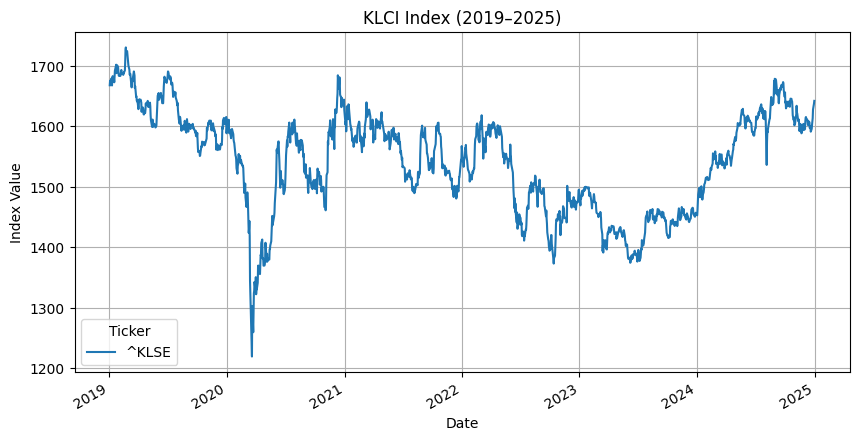

In [3]:
# Download KLCI index data
df_KLCI = yf.download('^KLSE', start='2019-01-01', end='2025-01-01')

# Save to CSV
df_KLCI.to_csv('KLCI_Historical_Data.csv')
print("Data saved to KLCI_Historical_Data.csv")

# Quick preview
print(df_KLCI.head())

# Plot closing prices
df_KLCI['Close'].plot(title='KLCI Index (2019–2025)', figsize=(10, 5))
plt.xlabel('Date')
plt.ylabel('Index Value')
plt.grid(True)
plt.show()


In [4]:
df_KLCI.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1470 entries, 2019-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, ^KLSE)   1470 non-null   float64
 1   (High, ^KLSE)    1470 non-null   float64
 2   (Low, ^KLSE)     1470 non-null   float64
 3   (Open, ^KLSE)    1470 non-null   float64
 4   (Volume, ^KLSE)  1470 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 68.9 KB


In [5]:
print(df_KLCI.columns)


MultiIndex([( 'Close', '^KLSE'),
            (  'High', '^KLSE'),
            (   'Low', '^KLSE'),
            (  'Open', '^KLSE'),
            ('Volume', '^KLSE')],
           names=['Price', 'Ticker'])


In [6]:
# daily close price
daily_close = df_KLCI[['Close']]
daily_point = daily_close.pct_change()
daily_point.fillna(0, inplace=True)
print(daily_point)

Price          Close
Ticker         ^KLSE
Date                
2019-01-02  0.000000
2019-01-03  0.004628
2019-01-04 -0.003610
2019-01-07  0.005624
2019-01-08 -0.003817
...              ...
2024-12-24  0.004254
2024-12-26  0.006681
2024-12-27  0.008948
2024-12-30  0.005859
2024-12-31  0.002839

[1470 rows x 1 columns]


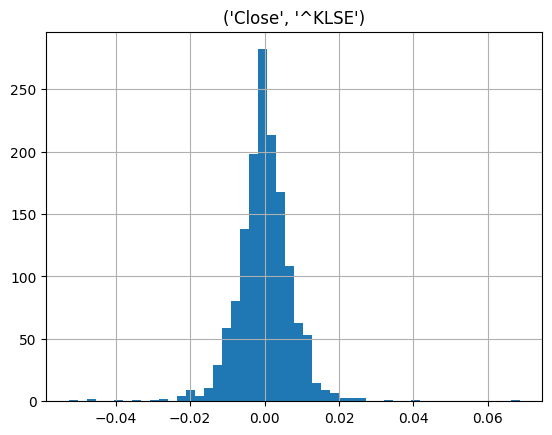

Price         Close
Ticker        ^KLSE
count   1470.000000
mean       0.000018
std        0.007526
min       -0.052613
25%       -0.003772
50%       -0.000138
75%        0.003921
max        0.068508


In [7]:
daily_point.hist(bins=50)
plt.show()
print(daily_point.describe())

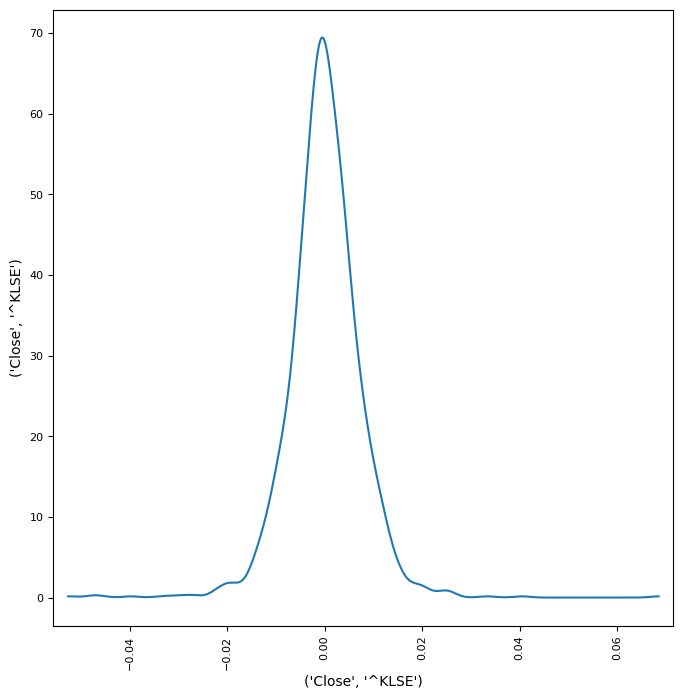

In [8]:
pd.plotting.scatter_matrix(daily_point, diagonal='kde', alpha=0.1,figsize=(8,8))
plt.show()

Moving Average : In finance, a moving average (MA) is a stock indicator commonly used in technical analysis. The reason for calculating the moving average of a stock is to help smooth out the price data by creating a constantly updated average price. By calculating the moving average, the impacts of random, short-term fluctuations on the price of a stock over a specified time frame are mitigated.

SMA vs EMA : The exponential moving average gives more weight to recent prices in an attempt to make them more responsive to new information. To calculate an EMA, the simple moving average (SMA) over a particular period is calculated first.

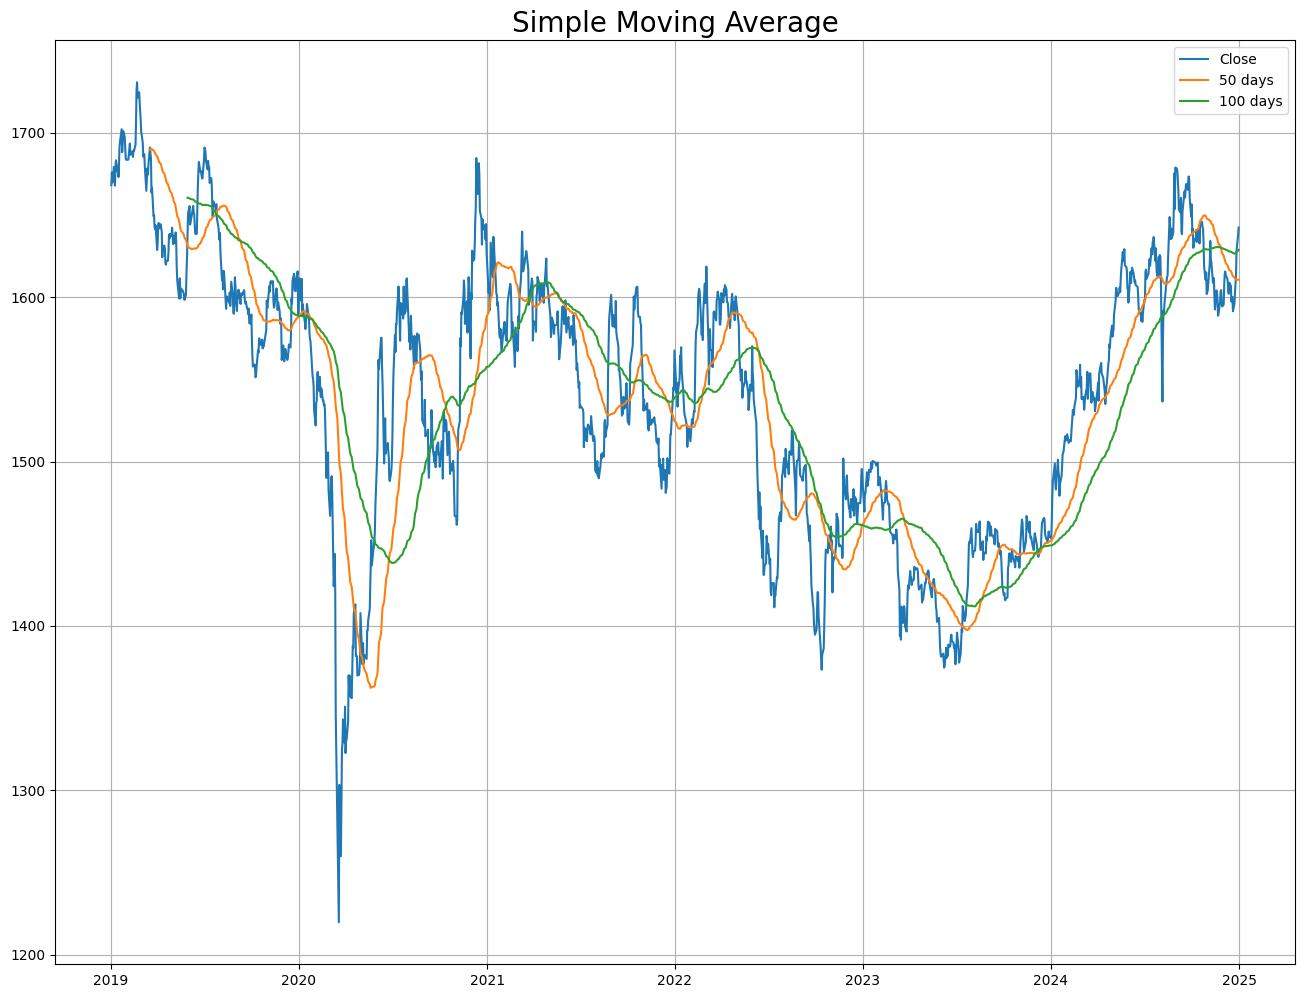

In [9]:
# plotting 50 days and 100 days simple moving average
daily_close = df_KLCI[['Close']]

df_KLCI['50'] = daily_close.rolling(window=50).mean() #50 days moving average 
df_KLCI['100'] = daily_close.rolling(window=100).mean() #100 days moving average 

plt.figure(figsize=(16,12))
plt.plot(df_KLCI['Close'], label='Close')
plt.plot(df_KLCI['50'], label='50 days')
plt.plot(df_KLCI['100'], label='100 days')
plt.title('Simple Moving Average', fontsize=20)
plt.grid()
plt.legend()
plt.show()

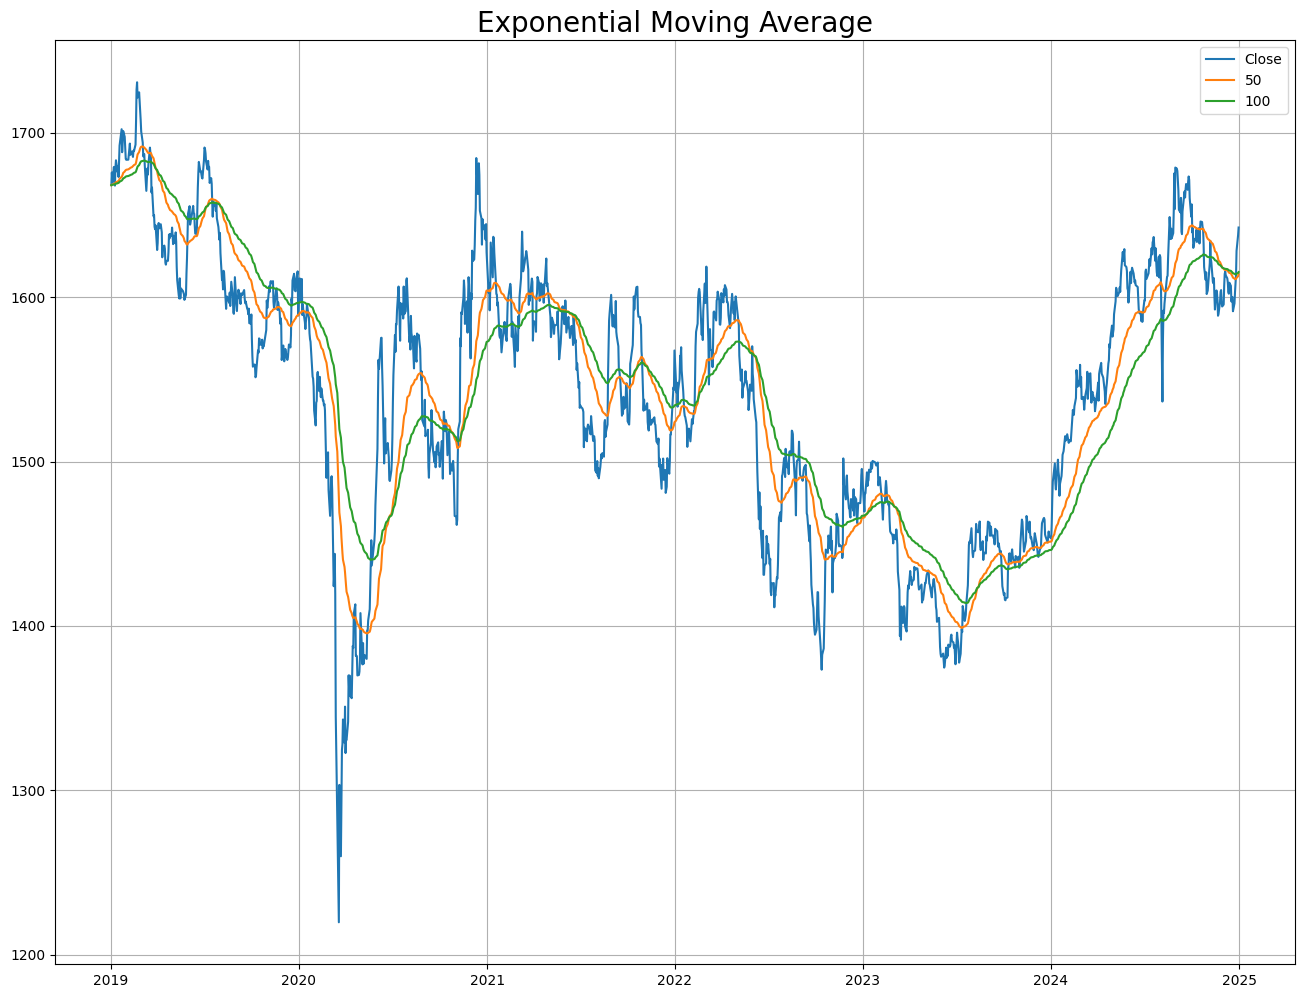

In [10]:
# plotting exponential moving average of 50 and 100 days

plt.figure(figsize=(16,12))
plt.plot(daily_close, label='Close')
plt.plot(daily_close.ewm(span=50, adjust=False).mean(), label='50')
plt.plot(daily_close.ewm(span=100, adjust=False).mean(), label='100')
plt.title('Exponential Moving Average', fontsize=20)
plt.legend()
plt.grid()
plt.show()


Volatility Calculation : The volatility of a stock is a measurement of the change in variance in a stock's returns over a specific period. We can compare the volatilities of stocks to examine which are riskier.

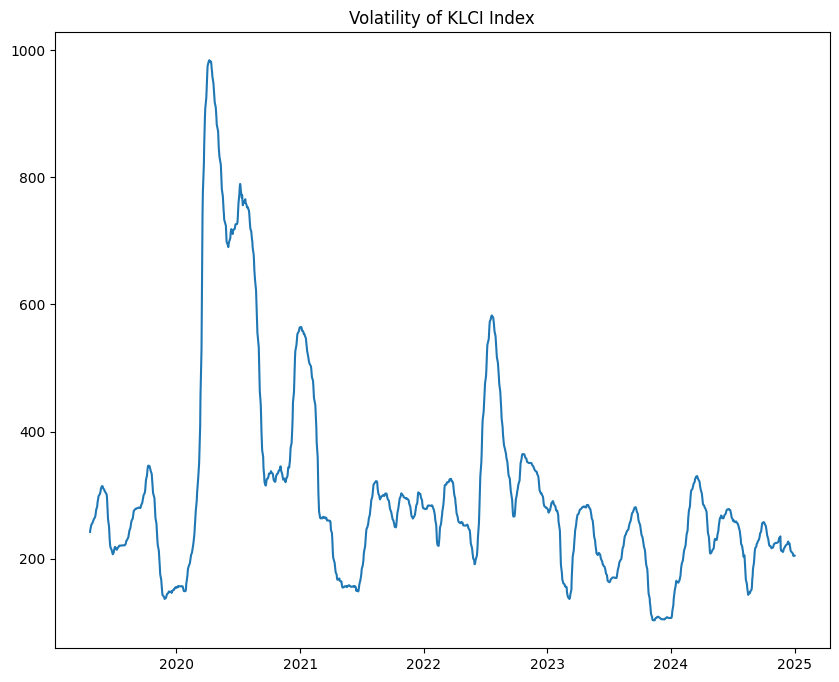

In [11]:
# KLCI volatitity calculation 

min_periods = 75 
vol = daily_close.rolling(min_periods).std() * np.sqrt(min_periods) 
plt.figure(figsize=(10, 8))
plt.plot(vol)
plt.title('Volatility of KLCI Index')
plt.show()

Moving Average Crossover¶
Among short- and long-term EMAs, they discovered that trading the crossovers of the 13-day and 48.5-day averages produced the largest returns. Buying the average 13/48.5-day “golden cross” produced an average 94-day 4.90 percent gain, better returns than any other combination.

In [12]:
# trading strategy
short_window = 13
long_window = 49

signals = pd.DataFrame(index=df_KLCI.index)
signals['signal'] = 0.0

signals['short_mavg'] = df_KLCI['Close'].rolling(window=short_window, min_periods=1, center=False).mean()
signals['long_mavg'] = df_KLCI['Close'].rolling(window=long_window, min_periods=1, center=False).mean()
signals['signal'][short_window:] = np.where(signals['short_mavg'][short_window:] 
                                            > signals['long_mavg'][short_window:], 1.0, 0.0)   

signals['positions'] = signals['signal'].diff()

C:\Users\badar\AppData\Local\Temp\ipykernel_20224\424078725.py:10: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  signals['signal'][short_window:] = np.where(signals['short_mavg'][short_window:]


In [13]:
df_KLCI

Price,Close,High,Low,Open,Volume,50,100
Ticker,^KLSE,^KLSE,^KLSE,^KLSE,^KLSE,,
Date,,,,,,,
2019-01-02,1668.109985,1694.099976,1666.069946,1693.510010,47769800,NaN,NaN
2019-01-03,1675.829956,1680.780029,1666.219971,1675.160034,69484500,NaN,NaN
2019-01-04,1669.780029,1676.550049,1668.150024,1672.579956,64869000,NaN,NaN
2019-01-07,1679.170044,1687.130005,1673.030029,1674.920044,144668500,NaN,NaN
2019-01-08,1672.760010,1686.369995,1670.670044,1685.719971,176071900,NaN,NaN
...,...,...,...,...,...,...,...
2024-12-24,1602.989990,1603.890015,1596.640015,1596.640015,95048400,1611.315999,1626.412701
2024-12-26,1613.699951,1615.280029,1602.790039,1603.579956,120934600,1610.750598,1627.184901


C:\Users\badar\AppData\Local\Temp\ipykernel_20224\2173345461.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax1.plot(signals.loc[signals.positions == 1.0].index,


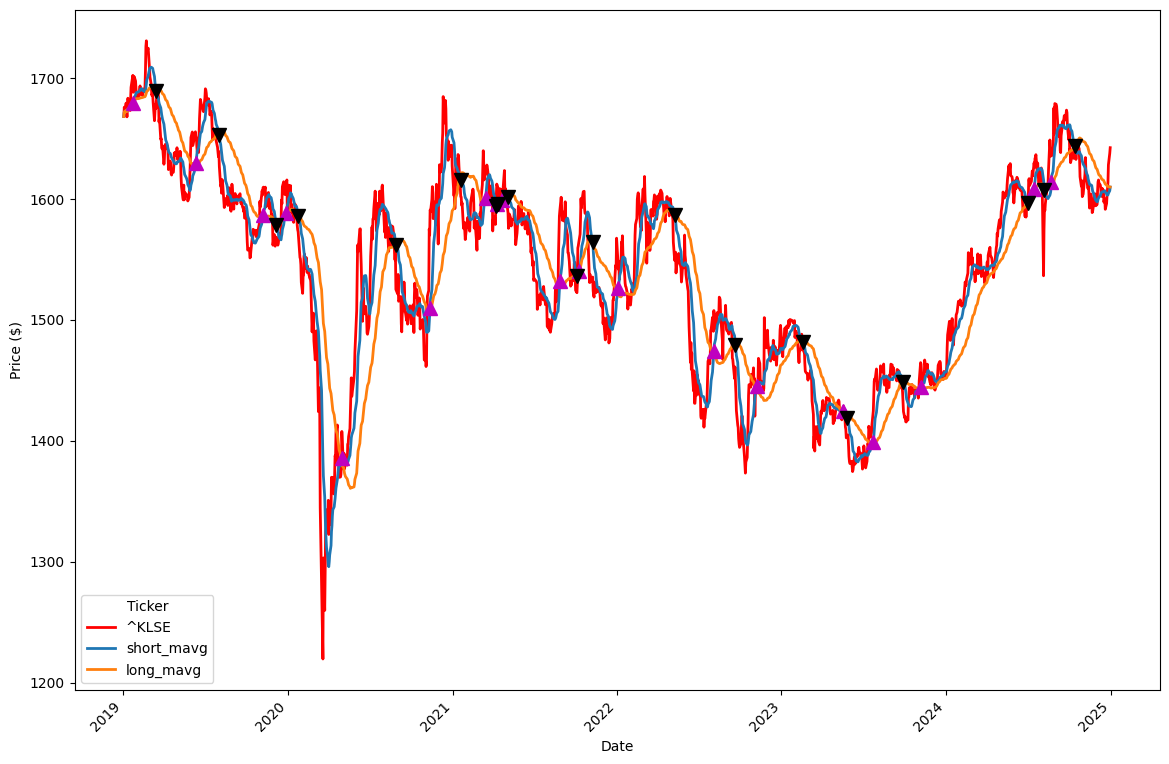

In [ ]:
# the 'KLCI' DataFrame is filtered between 2019 and the end of 2025
df_KLCI = df_KLCI.loc[pd.Timestamp('2019-01-01'):pd.Timestamp('2025-01-01')]

signals = signals.loc[pd.Timestamp('2019-01-01'):pd.Timestamp('2025-01-01')]

# Now plot with the correct period
fig = plt.figure(figsize=(14,10))
ax1 = fig.add_subplot(111, ylabel='Price ($)')

# Plot the 'Close' prices
df_KLCI['Close'].plot(ax=ax1, color='r', lw=2.)

# Plot the short and long moving averages from 'signals'
signals[['short_mavg', 'long_mavg']].plot(ax=ax1, lw=2.)

# Plot the buy signals
ax1.plot(signals.loc[signals.positions == 1.0].index, 
         signals.short_mavg[signals.positions == 1.0],
         '^', markersize=10, color='m')

# Plot the sell signals
ax1.plot(signals.loc[signals.positions == -1.0].index, 
         signals.short_mavg[signals.positions == -1.0],
         'v', markersize=10, color='k')

# Set major x-axis ticks to show every year and format to show the year only
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Rotate date labels for better readability
plt.setp(ax1.get_xticklabels(), rotation=45)

plt.show()